# 🚛 Tối ưu hóa Tuyến đường Thu gom Rác thải Sinh hoạt (CVRP) với Python & PyQGIS

**Mục tiêu:** Giải bài toán Định tuyến xe gom rác có ràng buộc tải trọng (*Capacitated Vehicle Routing Problem - CVRP*) trên mạng lưới đường giao thông thực tế.

**Dữ liệu đầu vào:**
* `Road_Network.shp`: Mạng lưới đường giao thông (VN-2000 UTM Zone 48N)
* `Orders.shp` (hoặc `DA_points.shp`, `AB_points.shp`, `TDH_points.shp`): Điểm phát sinh rác kèm thuộc tính khối lượng rác `KLCTR_up`
* `Depots.shp`: Vị trí trạm trung chuyển / gara xuất phát và xả rác

**Quy trình trong Notebook:**
1. Cài đặt và khai báo thư viện
2. Tiền xử lý & đồng nhất Hệ tọa độ sang VN-2000 UTM Zone 48N (hệ mét)
3. Xây dựng Đồ thị Mạng lưới đường giao thông (NetworkX Graph)
4. Snap các điểm gom rác và Depot vào đồ thị đường
5. Tính toán Ma trận Chi phí Khoảng cách (OD Distance Matrix) bằng Dijkstra
6. Cấu hình & Giải bài toán CVRP bằng Google OR-Tools
7. Tái tạo hình học tuyến đường (Polyline) theo mạng lưới đường & Xuất Shapefile kết quả
8. Trực quan hóa bản đồ kết quả (Matplotlib & Folium Interactive Map)


## 1. Cài đặt các thư viện cần thiết


In [1]:
!pip install geopandas shapely networkx ortools folium matplotlib mapclassify scipy


## 2. Khai báo thư viện & Thiết lập đường dẫn


In [2]:
import os
import math
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString, MultiLineString
import networkx as nx
from scipy.spatial import cKDTree
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp
import matplotlib.pyplot as plt
import folium

# Đường dẫn thư mục dữ liệu
DATA_DIR = r"d:\NLU_CS_2025\DT_chi_HVy\Data\Input_data"
ROAD_FILE = os.path.join(DATA_DIR, "Road_Network.shp")
DEPOT_FILE = os.path.join(DATA_DIR, "Depots.shp")
ORDERS_FILE = os.path.join(DATA_DIR, "Orders.shp")

# Hệ tọa độ mục tiêu: VN-2000 UTM Zone 48N (đơn vị: mét)
TARGET_CRS = "EPSG:32648"  # hoặc "EPSG:3405"


## 3. Đọc dữ liệu & Đồng nhất Hệ tọa độ (Reproject CRS)


In [3]:
# 1. Đọc dữ liệu Shapefile
gdf_roads = gpd.read_file(ROAD_FILE)
gdf_depots = gpd.read_file(DEPOT_FILE)
gdf_orders = gpd.read_file(ORDERS_FILE)

print("Số đoạn đường:", len(gdf_roads), "| CRS gốc:", gdf_roads.crs)
print("Số điểm Depot:", len(gdf_depots), "| CRS gốc:", gdf_depots.crs)
print("Số điểm Orders:", len(gdf_orders), "| CRS gốc:", gdf_orders.crs)

# 2. Chuyển toàn bộ về hệ tọa độ phẳng tính theo mét
if gdf_roads.crs != TARGET_CRS:
    gdf_roads = gdf_roads.to_crs(TARGET_CRS)
if gdf_depots.crs != TARGET_CRS:
    gdf_depots = gdf_depots.to_crs(TARGET_CRS)
if gdf_orders.crs != TARGET_CRS:
    gdf_orders = gdf_orders.to_crs(TARGET_CRS)

# 3. Xác định cột khối lượng chất thải rắn (Demand)
demand_col = 'KLCTR_up' if 'KLCTR_up' in gdf_orders.columns else gdf_orders.select_dtypes(include=[np.number]).columns[0]
gdf_orders[demand_col] = gdf_orders[demand_col].fillna(0).astype(int)

print(f"\n--> Cột khối lượng CTR được chọn: '{demand_col}'")
print(f"Tổng khối lượng rác toàn khu vực: {gdf_orders[demand_col].sum():,} kg")
print(f"Khối lượng trung bình mỗi điểm: {gdf_orders[demand_col].mean():.2f} kg")


Số đoạn đường: 9969 | CRS gốc: PROJCS["VN_2000_UTM_Zone_48N",GEOGCS["GCS_VN_2000"...
Số điểm Depot: 1 | CRS gốc: GEOGCS["GCS_WGS_1984"...
Số điểm Orders: 7835 | CRS gốc: GEOGCS["GCS_WGS_1984"...

--> Cột khối lượng CTR được chọn: 'KLCTR_up'
Tổng khối lượng rác toàn khu vực: 310,365 kg
Khối lượng trung bình mỗi điểm: 39.61 kg


## 4. Lựa chọn phạm vi thử nghiệm (Sampling)


In [4]:
SAMPLE_SIZE = 150  # Đặt None nếu muốn chạy toàn bộ

if SAMPLE_SIZE and len(gdf_orders) > SAMPLE_SIZE:
    sample_orders = gdf_orders.head(SAMPLE_SIZE).copy().reset_index(drop=True)
    print(f"Đang chạy phân tích với {len(sample_orders)} điểm gom...")
else:
    sample_orders = gdf_orders.copy().reset_index(drop=True)
    print(f"Chạy với toàn bộ {len(sample_orders)} điểm gom.")

depot_point = gdf_depots.geometry.iloc[0]


Đang chạy phân tích với 150 điểm gom...


## 5. Xây dựng Đồ thị Mạng lưới đường (NetworkX Graph)


In [5]:
def build_road_graph(roads_gdf):
    G = nx.Graph()
    for idx, row in roads_gdf.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        lines = geom.geoms if isinstance(geom, MultiLineString) else [geom]
        for line in lines:
            coords = list(line.coords)
            for i in range(len(coords) - 1):
                u = (round(coords[i][0], 2), round(coords[i][1], 2))
                v = (round(coords[i+1][0], 2), round(coords[i+1][1], 2))
                dist = Point(u).distance(Point(v))
                if dist > 0:
                    G.add_edge(u, v, weight=dist, length=dist)
    return G

print("Đang dựng đồ thị mạng lưới đường giao thông...")
road_graph = build_road_graph(gdf_roads)
print(f"Đồ thị hoàn thành: {road_graph.number_of_nodes()} nút giao, {road_graph.number_of_edges()} đoạn đường.")


Đang dựng đồ thị mạng lưới đường giao thông...
Đồ thị hoàn thành: 10332 nút giao, 11691 đoạn đường.


## 6. Snap Điểm gom rác và Depot vào Nút mạng gần nhất


In [6]:
nodes = list(road_graph.nodes())
node_coords = np.array(nodes)
kdtree = cKDTree(node_coords)

def snap_point(pt):
    _, idx = kdtree.query([pt.x, pt.y])
    return nodes[idx]

# Điểm vị trí 0 là Depot
depot_node = snap_point(depot_point)
order_nodes = [snap_point(geom) for geom in sample_orders.geometry]

all_locations = [depot_node] + order_nodes
all_demands = [0] + sample_orders[demand_col].tolist()

print(f"Tọa độ Depot trên lưới đường (Node 0): {depot_node}")
print(f"Đã snap thành công {len(order_nodes)} điểm gom rác vào đồ thị đường.")


Tọa độ Depot trên lưới đường (Node 0): (691827.13, 1212789.43)
Đã snap thành công 150 điểm gom rác vào đồ thị đường.


## 7. Xây dựng Ma trận Khoảng cách thực tế (OD Distance Matrix)


In [7]:
print("Đang tính toán ma trận khoảng cách ngắn nhất (Single-source Dijkstra)...")
unique_locs = list(set(all_locations))
sp_dict = {}
for u in unique_locs:
    try:
        sp_dict[u] = nx.single_source_dijkstra_path_length(road_graph, source=u, weight='weight')
    except Exception:
        sp_dict[u] = {}

n = len(all_locations)
distance_matrix = np.zeros((n, n), dtype=int)
for i in range(n):
    for j in range(n):
        if i == j:
            distance_matrix[i][j] = 0
        else:
            d = sp_dict.get(all_locations[i], {}).get(all_locations[j], None)
            if d is None:
                d = Point(all_locations[i]).distance(Point(all_locations[j])) * 1.4
            distance_matrix[i][j] = int(round(d))

print("Kích thước ma trận khoảng cách OD:", distance_matrix.shape)
print("Khoảng cách từ Depot đến 5 điểm đầu tiên (mét):", distance_matrix[0][:5].tolist())


Đang tính toán ma trận khoảng cách ngắn nhất (Single-source Dijkstra)...
Kích thước ma trận khoảng cách OD: (151, 151)
Khoảng cách từ Depot đến 5 điểm đầu tiên (mét): [0, 9115, 9115, 9115, 9115]


## 8. Cấu hình & Giải bài toán CVRP bằng Google OR-Tools


In [8]:
# --- THIẾT LẬP THÔNG SỐ XE VÀ ĐỘI XE ---
VEHICLE_CAPACITY = 3000   # Sức chứa tối đa của mỗi thùng xe (kg)
NUM_VEHICLES = 8          # Số lượng xe rác tối đa
DEPOT_INDEX = 0           # Điểm xuất phát và kết thúc lộ trình

def solve_cvrp(dist_matrix, demands, num_vehicles, vehicle_capacity, depot_idx=0):
    manager = pywrapcp.RoutingIndexManager(len(dist_matrix), num_vehicles, depot_idx)
    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return dist_matrix[from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    def demand_callback(from_index):
        from_node = manager.IndexToNode(from_index)
        return demands[from_node]

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index,
        0,
        [vehicle_capacity] * num_vehicles,
        True,
        'Capacity'
    )

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    search_parameters.time_limit.seconds = 10

    print("Đang giải bài toán tối ưu lộ trình...")
    solution = routing.SolveWithParameters(search_parameters)
    return manager, routing, solution

manager, routing, solution = solve_cvrp(
    distance_matrix, all_demands, NUM_VEHICLES, VEHICLE_CAPACITY, DEPOT_INDEX
)

if solution:
    print("=== TÌM THẤY LỘ TRÌNH TỐI ƯU THÀNH CÔNG ===")
else:
    print("Không tìm thấy nghiệm khả thi.")


Đang giải bài toán tối ưu lộ trình...
=== TÌM THẤY LỘ TRÌNH TỐI ƯU THÀNH CÔNG ===


## 9. Thống kê & Chi tiết Lộ trình của từng xe


In [9]:
routes_data = []
total_all_distance = 0
total_all_load = 0

if solution:
    for vehicle_id in range(NUM_VEHICLES):
        index = routing.Start(vehicle_id)
        route_distance = 0
        route_load = 0
        node_sequence = []
        
        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            route_load += all_demands[node_index]
            node_sequence.append(node_index)
            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(previous_index, index, vehicle_id)
        
        node_index = manager.IndexToNode(index)
        node_sequence.append(node_index)
        
        if len(node_sequence) > 2:
            num_pts = len(node_sequence) - 2
            routes_data.append({
                'Vehicle_ID': vehicle_id + 1,
                'Node_Sequence': node_sequence,
                'Distance_m': route_distance,
                'Load_kg': route_load,
                'Capacity_kg': VEHICLE_CAPACITY,
                'Num_Orders': num_pts
            })
            total_all_distance += route_distance
            total_all_load += route_load
            print(f"Xe {vehicle_id + 1}: Gom {num_pts} điểm | Tải: {route_load}/{VEHICLE_CAPACITY} kg ({(route_load/VEHICLE_CAPACITY)*100:.1f}%) | Quãng đường: {route_distance/1000:.2f} km")

    print("-" * 65)
    print(f"Tổng số xe sử dụng: {len(routes_data)} xe")
    print(f"Tổng khối lượng rác thu gom: {total_all_load:,} kg")
    print(f"Tổng quãng đường di chuyển: {total_all_distance / 1000:.2f} km")


Xe 1: Gom 74 điểm | Tải: 2972/3000 kg (99.1%) | Quãng đường: 22.98 km
Xe 2: Gom 21 điểm | Tải: 580/3000 kg (19.3%) | Quãng đường: 16.09 km
Xe 4: Gom 55 điểm | Tải: 2927/3000 kg (97.6%) | Quãng đường: 20.78 km
-----------------------------------------------------------------
Tổng số xe sử dụng: 3 xe
Tổng khối lượng rác thu gom: 6,479 kg
Tổng quãng đường di chuyển: 59.85 km


## 10. Tái tạo Tuyến đường Hình học (LineString) & Xuất Shapefile kết quả


In [10]:
route_geometries = []

for route in routes_data:
    v_id = route['Vehicle_ID']
    seq = route['Node_Sequence']
    full_path_coords = []
    
    for k in range(len(seq) - 1):
        u_node = all_locations[seq[k]]
        v_node = all_locations[seq[k+1]]
        try:
            path_nodes = nx.shortest_path(road_graph, source=u_node, target=v_node, weight='weight')
            full_path_coords.extend(path_nodes)
        except nx.NetworkXNoPath:
            full_path_coords.extend([u_node, v_node])
            
    if len(full_path_coords) >= 2:
        line_geom = LineString(full_path_coords)
        route_geometries.append({
            'Route_ID': v_id,
            'Load_kg': route['Load_kg'],
            'Dist_km': round(route['Distance_m'] / 1000, 2),
            'Num_Points': route['Num_Orders'],
            'geometry': line_geom
        })

gdf_routes = gpd.GeoDataFrame(route_geometries, crs=TARGET_CRS)

# Xuất ra file Shapefile để mở trực tiếp trên QGIS
OUTPUT_ROUTES_SHP = os.path.join(DATA_DIR, "Optimized_Routes.shp")
gdf_routes.to_file(OUTPUT_ROUTES_SHP)
print(f"Đã xuất shapefile tuyến đường thành công: {OUTPUT_ROUTES_SHP}")
display(gdf_routes[['Route_ID', 'Dist_km', 'Load_kg', 'Num_Points']])


Route_ID,Dist_km,Load_kg,Num_Points
1,22.98,2972,74
2,16.09,580,21
4,20.78,2927,55


## 11. Trực quan hóa Bản đồ Lộ trình (Matplotlib & Folium Map)


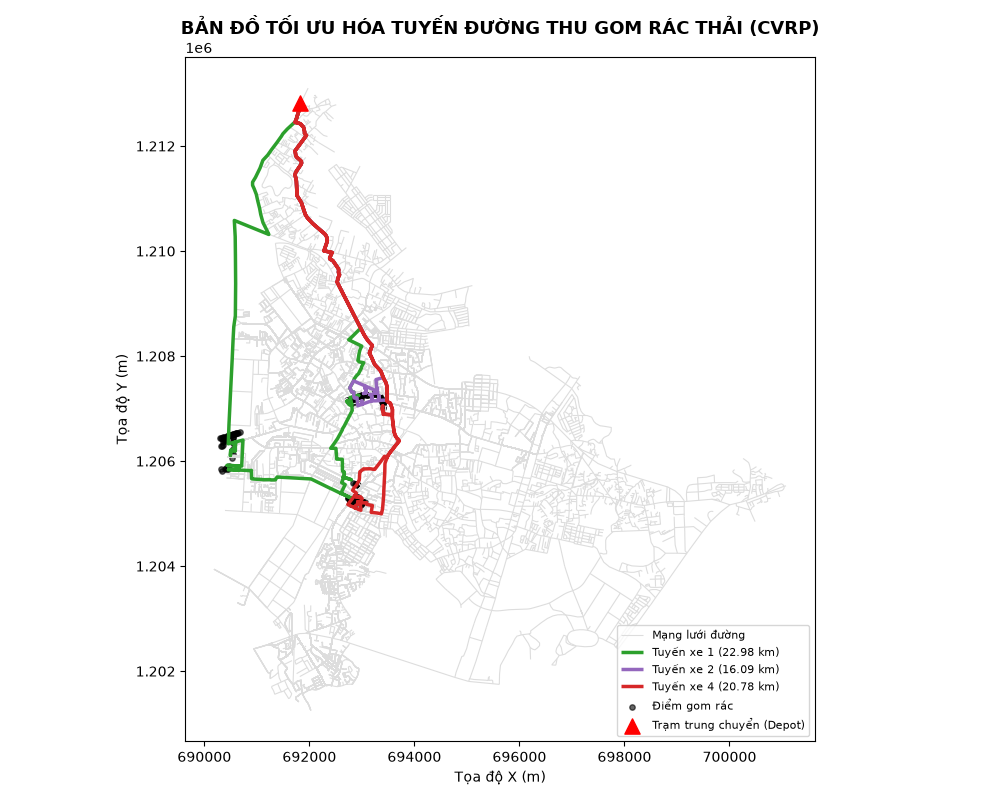

In [11]:
# 1. Trực quan hóa tổng quan bằng Matplotlib
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
gdf_roads.plot(ax=ax, color='#dddddd', linewidth=0.8, label='Mạng lưới đường')

colors = ['#1f77b4', '#2ca02c', '#9467bd', '#ff7f0e', '#d62728', '#17becf', '#bcbd22', '#8c564b']
for idx, row in gdf_routes.iterrows():
    c = colors[int(row['Route_ID']) % len(colors)]
    gpd.GeoSeries([row.geometry], crs=TARGET_CRS).plot(
        ax=ax, color=c, linewidth=2.5, label=f"Tuyến xe {row['Route_ID']} ({row['Dist_km']} km)"
    )

sample_orders.plot(ax=ax, color='black', markersize=15, alpha=0.6, label='Điểm gom rác')
gdf_depots.plot(ax=ax, color='red', markersize=120, marker='^', label='Trạm trung chuyển (Depot)', zorder=5)

ax.set_title("BẢN ĐỒ TỐI ƯU HÓA TUYẾN ĐƯỜNG THU GOM RÁC THẢI (CVRP)", fontsize=13, fontweight='bold')
ax.set_xlabel("Tọa độ X (m)")
ax.set_ylabel("Tọa độ Y (m)")
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


In [12]:
# 2. Bản đồ tương tác Web (Folium Map)
gdf_routes_wgs84 = gdf_routes.to_crs("EPSG:4326")
depot_wgs84 = gdf_depots.to_crs("EPSG:4326").geometry.iloc[0]

m = folium.Map(location=[depot_wgs84.y, depot_wgs84.x], zoom_start=14, tiles="cartodbpositron")
folium.Marker(
    location=[depot_wgs84.y, depot_wgs84.x],
    popup="<b>TRẠM TRUNG CHUYỂN (DEPOT)</b>",
    icon=folium.Icon(color="red", icon="home")
).add_to(m)

for idx, row in gdf_routes_wgs84.iterrows():
    c = colors[int(row['Route_ID']) % len(colors)]
    coords = [(lat, lon) for lon, lat in row.geometry.coords]
    folium.PolyLine(
        locations=coords,
        color=c,
        weight=4,
        opacity=0.85,
        tooltip=f"Tuyến xe {row['Route_ID']} - Quãng đường: {row['Dist_km']} km - Tải: {row['Load_kg']} kg ({row['Num_Points']} điểm)"
    ).add_to(m)

MAP_HTML = os.path.join(DATA_DIR, "Optimized_Routes_Map.html")
m.save(MAP_HTML)
print(f"Đã lưu bản đồ tương tác HTML tại: {MAP_HTML}")


Đã lưu bản đồ tương tác HTML tại: d:\NLU_CS_2025\DT_chi_HVy\Data\Input_data\Optimized_Routes_Map.html
